In [27]:
from ISMgas.fitting.systemic_redshift import Fitter
from ISMgas.SupportingFunctions import load_QFitsview_spectra, overlayAllLines
import matplotlib.pyplot as plt 

(3500.0, 5824.0)

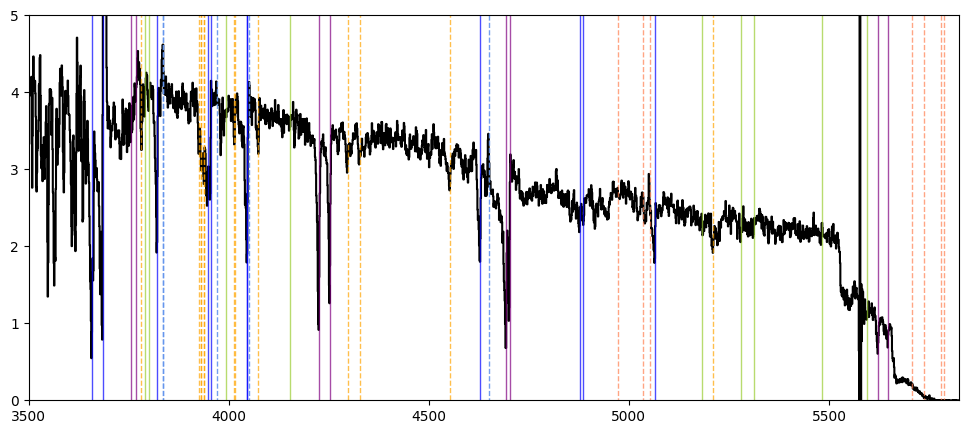

In [31]:
plt.figure(figsize=(12,5))
wave,flux = load_QFitsview_spectra("example_spec")

zs = 2.032 ## Guess redshift
overlayAllLines(zfactor = (1+zs))

flux *= 1e-2
## Make a mock error spectra
error_mock = flux*0.1
plt.ylim([0,5])
plt.xlim([3500, wave[-1]])

Running 1Running 0Running 4Running 3Running 5
Running 7Running 6Running 8Running 2
Running 9
Running 11Running 10



Running 13Running 12Running 14







Running 15
Running 16
Running 17
Running 18
Running 19
Running 20
Running 21
Running 22
Running 23
Running 24
Running 25
Running 26
Running 27
Running 28
Running 29
Running 30
Running 31
Running 32
Running 33
Running 34
Running 35
Running 36
Running 37
Running 38
Running 39
Running 40
Running 41
Running 42
Running 43
Running 44
Running 45
Running 46
Running 47
Running 48
Running 49


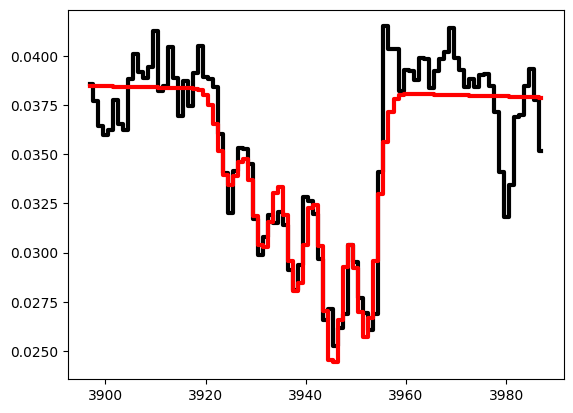

In [32]:
zFit = Fitter(
    wave = wave,
    flux= flux,
    err = error_mock,
    zs = zs,
    objid = 'test'
)
priors = {
        'p0':{'value':-0.00001, 'min':-0.04, 'max':0},
        'p1':{'value':-0.00001, 'min':-0.04, 'max':0},
        'p2':{'value':-0.00001, 'min':-0.04, 'max':0},
        'p3':{'value':-0.00001, 'min':-0.04,   'max':0},
        'p4':{'value':-0.00001, 'min':-0.04,   'max':0},
        'p5':{'value':-0.001,  'min':-0.05,   'max':0},
        'p6':{'value':0.001,   'min':0, 'max':0.000001},
        'z1':{'value':zs, 'min':zs - 0.001, 'max':zs + 0.001},
        'z2':{'value':zs - 0.002, 'min':zs - 0.005, 'max':zs + 0.005},
        'z3':{'value':zs, 'min':zs - 0.001, 'max':zs + 0.001},   
        'sigma1':{'value':0.0001,   'min':0.0, 'max':0.0005},
        'sigma2':{'value':0.0001,   'min':0.0, 'max':0.0005},
        'sigma3':{'value':0.0001,   'min':0.0, 'max':0.0005},
        'p9':{'value':0.05,   'min':-0.05, 'max':1},
        'p10':{'value':-0.001,  'min':-1, 'max':1 }
    }

results = zFit.stellar1300(niter=50, plotting=True, priors=priors)

In [33]:
results

{'best_fit': {'zstars': [2.031889726027109, 0.00020782894421685945],
  'zism': [2.029945491675811, 0.0002168514218299551],
  'zfineem': [2.031983664897865, 0.0011506150545743993],
  'sigma_stellar': [0.00020862308115254154, 2.2189345411436453e-05],
  'sigma_ism': [0.0002142327891595975, 1.2273582580606099e-05],
  'sigma_fineem': [0.0002928762595024992, 0.0001536130637659751],
  'p0': [-0.0047891149228612845, 0.0010969766592887958],
  'p1': [-5.254991088110561e-08, 7.778229457641624e-08],
  'p2': [-0.008063122887776872, 0.0011129988383985123],
  'p3': [-0.010169446777048724, 0.0011508849675467912],
  'p4': [-0.013914222832084613, 0.0008184399467835964],
  'p5': [-0.012316209902460011, 0.000919813515069385],
  'p6': [9.351990932327936e-07, 9.189796833817183e-08],
  'p9': [0.0644889224455277, 0.008408308838554571],
  'p10': [0.22439903258761318, 0.057014914711220846],
  'wave': <Column name='Wave' dtype='float64' length=91>
  3897.0
  3898.0
  3899.0
  3900.0
  3901.0
  3902.0
  3903.0
  

(3700.0, 4100.0)

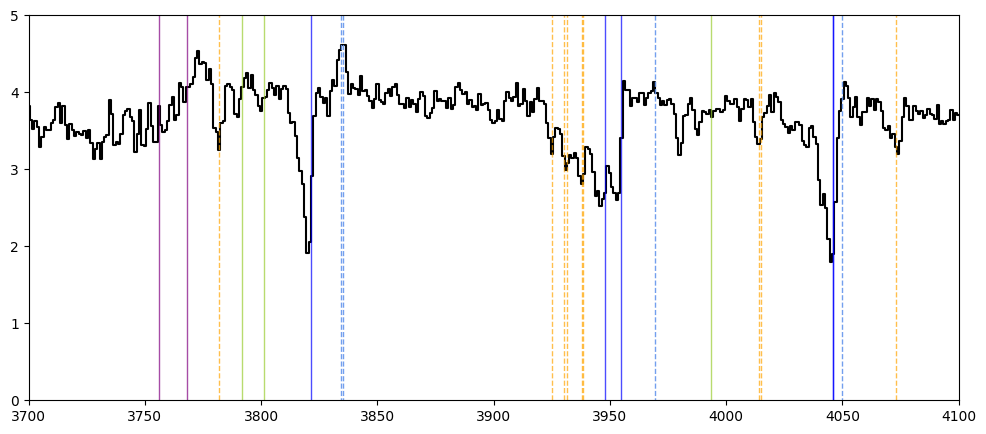

In [37]:
plt.figure(figsize=(12,5))
wave,flux = load_QFitsview_spectra("example_spec")

zs = results['best_fit']['zstars'][0] ## best fit redshift
overlayAllLines(zfactor = (1+zs))
plt.ylim([0,5])
plt.xlim([3700, 4100])